In [1]:
import os

# Set the environment variable to avoid printing the error message
os.environ["EQX_ON_ERROR"] = "nan"

import numpy as np
import jax
import healpy as hp

import matplotlib.pyplot as plt

import megabuster.compsep
import megabuster.io
import megabuster.minimizers
import megabuster.obsmat
import megabuster.precomputations
import megabuster.tools

jax.config.update("jax_enable_x64", True)


# Generating input CMB and input mask

In [2]:
from fgbuster import get_observation, get_instrument

nside = 128 
npix = 12*nside**2
nstokes = 2


frequencies = np.array([27, 39, 93, 145, 225, 280])

n_freq = len(frequencies)

# Get simulated map
instrument = get_instrument('SO_SAT')


np.random.seed(42)
input_freq_maps = get_observation(instrument, 'c1d0s0', nside=nside, noise=False)

np.random.seed(42)
input_cmb = get_observation(instrument, 'c1', nside=nside, noise=False)


np.float64(0.134796142578125)

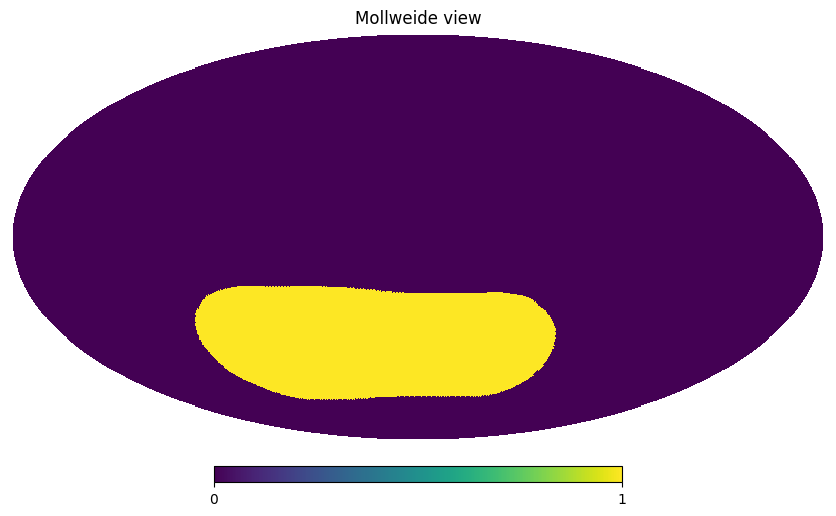

In [3]:
def make_mask(nhits_path, zero_threshold, nside):
    nhits_map = hp.read_map(nhits_path)
    nhits_smoothed = hp.smoothing(
        hp.ud_grade(nhits_map, nside, power=-2, dtype=np.float64),
        fwhm=np.pi/180)
    nhits_smoothed[nhits_smoothed < 0] = 0
    nhits_smoothed /= np.amax(nhits_smoothed)
    binary_mask = np.zeros_like(nhits_smoothed)
    binary_mask[nhits_smoothed > zero_threshold] = 1
    fsky = np.sum(binary_mask) / len(binary_mask)

    return binary_mask, fsky

nside_out = 128  # Output nside for the mask

# path_MSS = '/lustre/fswork/projects/rech/nih/commun/megatop/MSS2/ivar/'
path_MSS = '/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/'
zero_threshold = 0.1
path_nhits = path_MSS+f"sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_ivar_healpix.fits"
mask_B, fsky = make_mask(path_nhits, zero_threshold, nside=nside_out)

theta, phi = hp.pix2ang(nside=nside_out, ipix=np.arange(mask_B.size), lonlat=True)

mask_south = np.zeros_like(mask_B)

mask_south[theta < 115] = 1
mask_south[theta > 280] = 1
mask_south[phi < -35] = 1
mask_south[phi > -15] = 0

mask_B_ring = mask_B * mask_south
mask_B_nest = hp.reorder(mask_B_ring, r2n=True)

mask_indices = mask_B_nest != 0

hp.mollview(mask_B_nest, nest=True)
f_sky = mask_B_nest.sum() / mask_B_nest.size
f_sky

# Preparing path and loading obsmat

In [4]:
# Preparing paths

path_scratch = '/pscratch/sd/m/mag/fast_MSS2_obsmat/'
path_precomputations = path_scratch
# path_precomputations = '/lustre/fswork/projects/rech/nih/commun/megatop/precomputations/'

path_N = '/pscratch/sd/b/beringue/BB-AWG/MEGATOP/2501_obsmat_filtering/covmat/pixel_noise_cov_preprocessed.npy'

# Prepare the paths of observation matrices 

path_save_obsmat_file = "sobs_RC1.r01_SAT{}_mission_f{:03d}_4way_{}_sky_obsmat_healpix_"


all_incomplete_path_save_obsmat_file = [path_save_obsmat_file.format(4, freq, 'coadd') for freq in [30, 40]]
all_incomplete_path_save_obsmat_file += [path_save_obsmat_file.format(1, freq, 'coadd') for freq in [90, 150]]
all_incomplete_path_save_obsmat_file += [path_save_obsmat_file.format(3, freq, 'coadd') for freq in [230, 290]]

all_path_save_obsmat_file = [path_scratch + path for path in all_incomplete_path_save_obsmat_file]


n_pix = mask_B_nest.sum()

In [5]:
# Preparing the inverse noise covariance matrix --------------------------------
print("Loading the inverse noise covariance matrix from", path_N, flush=True)
def load_N_matrix(path_N):
    N_matrix = np.load(path_N)
    if N_matrix.ndim != 2:
        output = []
        for i in range(N_matrix.shape[0]):
            output.append(hp.ud_grade(N_matrix[i], nside_out=nside, power=2))
        N_matrix = np.array(output)
    return N_matrix

N_matrix = load_N_matrix(path_N)



Loading the inverse noise covariance matrix from /pscratch/sd/b/beringue/BB-AWG/MEGATOP/2501_obsmat_filtering/covmat/pixel_noise_cov_preprocessed.npy


Here the full observation matrices are loaded to filter the input data

In [6]:
%%time
# list_scipy_obsmat = [megabuster.load_obsmat_mask(path_obsmat, size_obsmat=3*npix, mask_stacked=None, return_diagonal_term=False) for path_obsmat in all_path_save_obsmat_file]
list_scipy_obsmat = megabuster.io.load_all_obsmat(all_path_save_obsmat_file, size_obsmat=3*npix, nstokes=3*npix, kind='precomputations_scipy', mask_stacked=None)
list_diag_obsmat = np.array([obsmat.diagonal() for obsmat in list_scipy_obsmat]).reshape((n_freq, 3, npix))[:,1:,:]


Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix_
CPU times: user 1min 16s, sys: 6min 48s, total: 8min 4s
Wall time: 8min 15s


In [7]:
%%time
freq_maps_preprocessed_QU_masked = np.zeros((n_freq, 3, npix))

for i in range(n_freq):
    print(i)
    freq_maps_preprocessed_QU_masked[i,...] = hp.reorder(
        list_scipy_obsmat[i].dot(
            hp.reorder(
                input_freq_maps[i,...],r2n=True).ravel()
            ).reshape(input_freq_maps[i,...].shape), n2r=True)

freq_maps_preprocessed_QU_masked = freq_maps_preprocessed_QU_masked[:,1:,:] * mask_B_ring

0
1
2
3
4
5
CPU times: user 8.09 s, sys: 70.2 ms, total: 8.16 s
Wall time: 8.16 s


In [8]:
del list_scipy_obsmat

And now we prepare the observation matrices to be used in the compsep

In [9]:
%%time
indices_mask = np.arange(npix)[mask_indices]

# Retrieve mask indices for Q and U (omitting T)
mask_stacked = np.hstack((indices_mask + npix, indices_mask + 2*npix))

#list_scipy_obsmat_masked = [megabuster.load_obsmat_mask(path_obsmat, size_obsmat=3*npix, mask_stacked=mask_stacked, return_diagonal_term=False) for path_obsmat in all_path_save_obsmat_file]
list_scipy_obsmat_masked = megabuster.io.load_all_obsmat(all_path_save_obsmat_file, size_obsmat=3*npix, nstokes=3*npix, kind='precomputations_scipy', mask_stacked=mask_stacked)


Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix_
CPU times: user 48.1 s, sys: 3min 45s, total: 4min 33s
Wall time: 4min 41s


In [10]:
all_paths_precomputations = [path + '_south' for path in all_path_save_obsmat_file]
all_paths_precomputations

['/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix__south',
 '/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix__south',
 '/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix__south',
 '/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix__south',
 '/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix__south',
 '/pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix__south']

In [11]:
%%time

# Already done so not necessary to redo it

list_threshold = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01] # Thresholds for each frequency
#megabuster.io.compute_threshold_matrices(list_threshold, list_scipy_obsmat_masked, all_paths_precomputations, nstokes=2, disable_tqdm)

CPU times: user 6 μs, sys: 9 μs, total: 15 μs
Wall time: 28.6 μs


In [12]:
%%time

all_paths_precomputations_big = [path + f'_south_threshold_{list_threshold[i]}' for i, path in enumerate(all_path_save_obsmat_file)]

obsmat_operator_cg = megabuster.io.load_all_obsmat(all_paths_precomputations_big, n_pix, nstokes=2, kind='precomputations_indices', mask_stacked=None)


CPU times: user 2.98 s, sys: 1.97 s, total: 4.95 s
Wall time: 2.62 s


In [13]:
%%time
all_paths_precomputations_south = [path + f'_south' for i, path in enumerate(all_path_save_obsmat_file)]

freq_obsmat_operator = megabuster.io.load_all_obsmat(all_paths_precomputations_south, size_obsmat=n_pix, nstokes=2, kind='precomputations_indices', mask_stacked=None)


CPU times: user 1min 38s, sys: 2min 10s, total: 3min 48s
Wall time: 2min 43s


In [14]:
noisecov_QU_masked = N_matrix[:,1:,:] * mask_B_ring
inverse_noisecov_QU_masked = np.zeros_like(noisecov_QU_masked)
inverse_noisecov_QU_masked[noisecov_QU_masked != 0] = 1./noisecov_QU_masked[noisecov_QU_masked != 0]
inverse_noisecov_QU_masked.shape

(6, 2, 196608)

In [21]:
%%time
res_sanity = megabuster.compsep.perform_compsep(
        first_guess_params={'beta_dust': np.array(1.54), 'beta_pl': np.array(-3.0)},
        fixed_params={'temp_dust': 20.0},
        sky_map=input_freq_maps[:,1:,:] * mask_B_ring,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        binary_mask=mask_B_ring,
        obs_mat_operator=None, 
        obsmat_operator_rhs=None,
        diag_obsmat_matrices=None,
        max_iter=20,
        tol=1e-6,
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Minimization launched!! Preparing the retrieving of the maps . . .
Converged in 2 iterations
CPU times: user 13 s, sys: 419 ms, total: 13.4 s
Wall time: 6.86 s


In [22]:
res_sanity.x

array([ 1.54000014, -2.99999907])

In [122]:
%%time
res_0 = perform_compsep(
        first_guess_params={'beta_dust': np.array(1.54), 'beta_pl': np.array(-3.0)},
        fixed_params={'temp_dust': 20.0},
        sky_map=freq_maps_preprocessed_QU_masked,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        binary_mask=mask_B_ring,
        obs_mat_operator=None, 
        obsmat_operator_rhs=None,
        diag_obsmat_matrices=None,
        max_iter=20,
        tol=1e-6,
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Minimization launched!! Preparing the retrieving of the maps . . .
Converged in 2 iterations
CPU times: user 10.2 s, sys: 485 ms, total: 10.6 s
Wall time: 5.39 s


In [123]:
res_0.x

array([ 1.5329246 , -3.00886935])

In [130]:
%%time
res = megabuster.compsep.perform_compsep(
        first_guess_params={'beta_dust': np.array(1.54), 'beta_pl': np.array(-3.0)},
        fixed_params={'temp_dust': 20.0},
        sky_map=freq_maps_preprocessed_QU_masked,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        binary_mask=mask_B_ring,
        obs_mat_operator=obsmat_operator_cg, 
        obsmat_operator_rhs=freq_obsmat_operator.T,
        diag_obsmat_matrices=list_diag_obsmat,
        max_iter=20,
        tol=1e-6,
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Using diag offdiag obsmat
Launching minimization!!
Converged in 77 iterations
Converged in 77 iterations
Converged in 76 iterations
Converged in 80 iterations
Converged in 77 iterations
Converged in 77 iterations
Converged in 77 iterations
Converged in 77 iterations
Converged in 79 iterations
Converged in 79 iterations
Converged in 76 iterations
Converged in 76 iterations
Converged in 77 iterations
Converged in 77 iterations
Converged in 79 iterations
Minimization launched!! Preparing the retrieving of the maps . . .
Converged in 77 iterations
CPU times: user 14min 35s, sys: 34.2 s, total: 15min 9s
Wall time: 8min 1s


In [131]:
res.x

array([ 1.54480745, -3.01084028])

In [132]:
res.A_maxL

array([[1.00000000e+00, 4.83966636e-02, 4.08570526e-01],
       [1.00000000e+00, 8.59059833e-02, 1.37806471e-01],
       [1.00000000e+00, 3.68260553e-01, 1.20474905e-02],
       [1.00000000e+00, 9.22715184e-01, 4.26065260e-03],
       [1.00000000e+00, 3.15449408e+00, 2.18179458e-03],
       [1.00000000e+00, 7.16398226e+00, 1.96742830e-03]])

In [133]:
res.success

Array(True, dtype=bool)

In [134]:
res.message

'Optimization finished after 5 iterations out of 20 allowed.'

In [135]:
%%time
other_final_map = res.W_maxL(freq_maps_preprocessed_QU_masked)

Converged in 77 iterations
CPU times: user 1min 16s, sys: 4.49 s, total: 1min 21s
Wall time: 13.3 s


In [137]:
np.abs(other_final_map-res.s).max() < 1e-15

np.True_

In [138]:
final_map = res.s

In [139]:
final_map.shape

(3, 2, 196608)

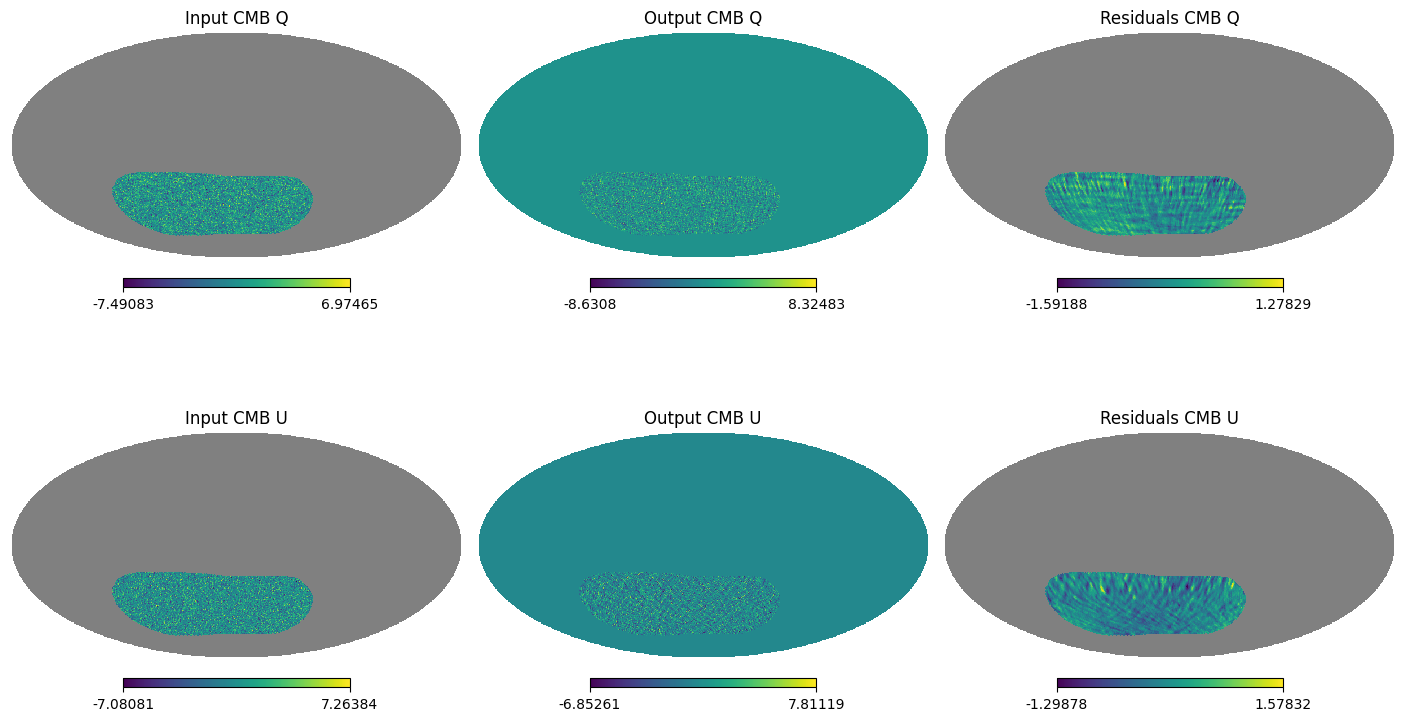

In [152]:
extended_map = np.ones((nstokes, npix))*hp.UNSEEN

plt.figure(figsize=(14,8))

ncol = 3

label_stokes = ['Q', 'U']

extended_map[:, mask_indices] = input_cmb[0,1:,mask_indices].T
for i in range(nstokes):
    hp.mollview(extended_map[i], sub=(2, ncol, 1 + i*ncol), title=f'Input CMB {label_stokes[i]}', nest=True)

#extended_map[:, mask_indices] = final_map[0,:,:]

for i in range(nstokes):
    hp.mollview(final_map[0,i], sub=(2, ncol, 1 + i*ncol + 1), title=f'Output CMB {label_stokes[i]}') #, nest=True)

extended_map = np.ones((nstokes, npix))*hp.UNSEEN
extended_map[:, mask_B_ring!=0] = (input_cmb[0,1:,mask_B_ring!=0] - final_map[0,:,mask_B_ring!=0]).T
for i in range(nstokes):
    hp.mollview(extended_map[i], sub=(2, ncol, 1 + i*ncol + 2), title=f'Residuals CMB {label_stokes[i]}') #, nest=True)


In [154]:
extended_map_input_nested = np.zeros((3, npix))
extended_map_input_nested[1:, mask_indices] = hp.reorder(input_cmb[0,1:],r2n=True)[...,mask_indices]

extended_map_output = np.zeros((3, npix))
extended_map_output[1:, mask_B_ring!=0] = final_map[0,:,mask_B_ring!=0].T

extended_map_input = hp.reorder(extended_map_input_nested, n2r=True)
#extended_map_output = hp.reorder(extended_map_output_nested, n2r=True)


In [155]:
lmax = 2*nside

In [156]:
c_ell_input = hp.anafast(extended_map_input, lmax=lmax)
c_ell_output = hp.anafast(extended_map_output, lmax=lmax)#/f_sky

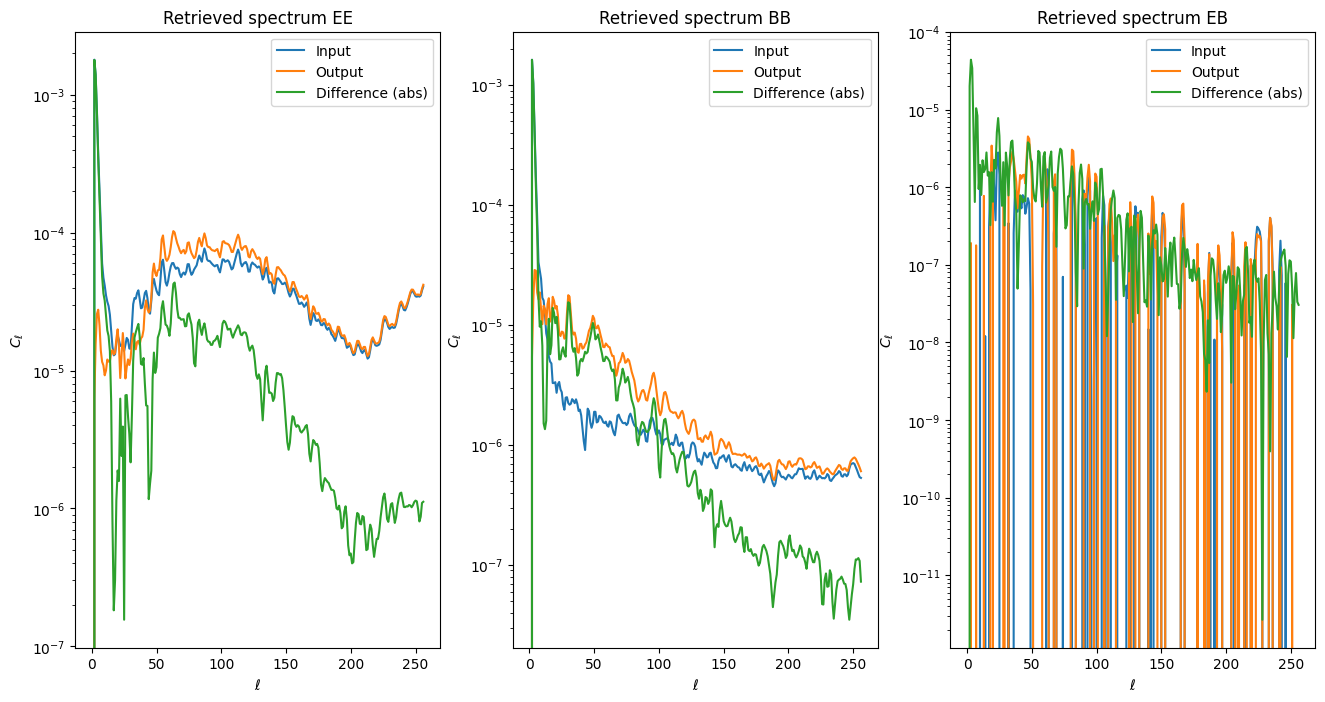

In [157]:
correl_list = ['TT', 'EE', 'BB', 'TE', 'EB', 'TB']

plt.figure(figsize=(16,8))
for k, i in enumerate([1,2,4]):
    plt.subplot(131+k)
    plt.plot(c_ell_input[i], label='Input')
    plt.plot(c_ell_output[i], label='Output')
    plt.plot(np.abs(c_ell_input[i]-c_ell_output[i]), label='Difference (abs)')
    plt.yscale('log')
    plt.title(f"Retrieved spectrum {correl_list[i]}")
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$C_\ell$")
    plt.legend()
plt.show()